In [1]:
import os
import numpy as np
from tqdm import tqdm

In [2]:
import torch

SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(DEVICE)

cuda


## 1. Data 불러오기

In [3]:
# # 7z 설치
# !apt-get -qq install p7zip-full

# archive = "/rendered_256x256.7z"
# extract = "/Sketchy"

# !mkdir -p $extract

# # 원본 sketch만 해제
# !7z x "$archive" "256x256/sketch/tx_000000000000/*" -o"$extract" -y

## 2. DataLoader 정의 및 Data Augmentation

In [4]:
data_root = "./Sketchy/256x256/sketch/tx_000000000000"

In [5]:
catchmind_classes = [

    # 동물
    'cat','dog','bear','elephant','giraffe','lion','tiger',
    'horse','cow','pig','rabbit','duck','penguin','frog','fish',

    # 음식
    'apple','banana','hamburger','hotdog',
    'pizza','bread','strawberry','pineapple',

    # 교통
    'airplane','bicycle','motorcycle',
    'pickup_truck','helicopter','rocket','sailboat',

    # 사물
    'chair','table','door','window','hat','eyeglasses',
    'hammer','scissors','guitar','violin','umbrella','shoe',

    # 자연/기타
    'flower','tree','volcano','starfish','windmill',
    'castle','cabin','hot-air_balloon'
]

In [6]:
from torchvision.datasets import ImageFolder

class FilteredImageFolder(ImageFolder):

    def __init__(self, root, selected_classes, transform=None):

        super().__init__(
            root=root,
            transform=transform
        )

        selected = set(selected_classes)

        # 사용할 클래스 index
        valid_idx = {self.class_to_idx[c] for c in selected}

        # 해당 클래스만 유지
        self.samples = [s for s in self.samples if s[1] in valid_idx]
        self.targets = [s[1] for s in self.samples]

        # label 재매핑
        new_map = {c:i for i,c in enumerate(selected_classes)}

        old_to_new = {self.class_to_idx[c]:new_map[c] for c in selected_classes}

        self.samples = [(path, old_to_new[label]) for path,label in self.samples]
        self.targets = [old_to_new[t] for t in self.targets]
        self.classes = selected_classes
        self.class_to_idx = {c:i for i,c in enumerate(selected_classes)}

In [7]:
# from torchvision.datasets import ImageFolder

# full_dataset = ImageFolder(root=data_root)

# targets = full_dataset.targets
# indices = np.arange(len(targets))

# classes = full_dataset.classes

# print("the # of classes:", len(classes))
# print(classes)


full_dataset = FilteredImageFolder(
    root=data_root,
    selected_classes=catchmind_classes
)

targets = full_dataset.targets
indices = np.arange(len(targets))

classes = full_dataset.classes

print("the # of classes:", len(classes))
print(classes)

the # of classes: 50
['cat', 'dog', 'bear', 'elephant', 'giraffe', 'lion', 'tiger', 'horse', 'cow', 'pig', 'rabbit', 'duck', 'penguin', 'frog', 'fish', 'apple', 'banana', 'hamburger', 'hotdog', 'pizza', 'bread', 'strawberry', 'pineapple', 'airplane', 'bicycle', 'motorcycle', 'pickup_truck', 'helicopter', 'rocket', 'sailboat', 'chair', 'table', 'door', 'window', 'hat', 'eyeglasses', 'hammer', 'scissors', 'guitar', 'violin', 'umbrella', 'shoe', 'flower', 'tree', 'volcano', 'starfish', 'windmill', 'castle', 'cabin', 'hot-air_balloon']


In [8]:
from collections import Counter

idx_to_class = {v:k for k,v in full_dataset.class_to_idx.items()}

count = Counter(targets)
sample_per_class = {idx_to_class[idx]:n for idx, n in count.items()}

# print("total samples:", count.total())
print(sample_per_class)

{'airplane': 709, 'apple': 551, 'banana': 635, 'bear': 722, 'bicycle': 614, 'bread': 563, 'cabin': 546, 'castle': 608, 'cat': 692, 'chair': 669, 'cow': 728, 'dog': 692, 'door': 578, 'duck': 724, 'elephant': 661, 'eyeglasses': 538, 'fish': 530, 'flower': 518, 'frog': 608, 'giraffe': 673, 'guitar': 528, 'hamburger': 524, 'hammer': 631, 'hat': 529, 'helicopter': 746, 'horse': 738, 'hot-air_balloon': 619, 'hotdog': 634, 'lion': 697, 'motorcycle': 643, 'penguin': 537, 'pickup_truck': 698, 'pig': 676, 'pineapple': 605, 'pizza': 606, 'rabbit': 668, 'rocket': 600, 'sailboat': 659, 'scissors': 558, 'shoe': 546, 'starfish': 519, 'strawberry': 600, 'table': 563, 'tiger': 743, 'tree': 533, 'umbrella': 546, 'violin': 554, 'volcano': 554, 'windmill': 598, 'window': 554}


In [9]:
# 클래스 별 sample 수 제한
from collections import defaultdict

MAX_PER_CLASS = 200

class_indices = defaultdict(list)

for idx, label in enumerate(targets):
    class_indices[label].append(idx)

selected_indices = []

for label, idx_list in class_indices.items():

    idx_list = np.array(idx_list)

    # shuffle
    np.random.shuffle(idx_list)

    # 최대 N개만 선택
    selected = idx_list[:MAX_PER_CLASS]
    selected_indices.extend(selected)


indices = np.array(selected_indices)
targets = np.array(targets)[indices]

count = Counter(targets)
sample_per_class = {idx_to_class[idx]:n for idx, n in count.items()}

# print("total samples:", count.total())
print(sample_per_class)

{'airplane': 200, 'apple': 200, 'banana': 200, 'bear': 200, 'bicycle': 200, 'bread': 200, 'cabin': 200, 'castle': 200, 'cat': 200, 'chair': 200, 'cow': 200, 'dog': 200, 'door': 200, 'duck': 200, 'elephant': 200, 'eyeglasses': 200, 'fish': 200, 'flower': 200, 'frog': 200, 'giraffe': 200, 'guitar': 200, 'hamburger': 200, 'hammer': 200, 'hat': 200, 'helicopter': 200, 'horse': 200, 'hot-air_balloon': 200, 'hotdog': 200, 'lion': 200, 'motorcycle': 200, 'penguin': 200, 'pickup_truck': 200, 'pig': 200, 'pineapple': 200, 'pizza': 200, 'rabbit': 200, 'rocket': 200, 'sailboat': 200, 'scissors': 200, 'shoe': 200, 'starfish': 200, 'strawberry': 200, 'table': 200, 'tiger': 200, 'tree': 200, 'umbrella': 200, 'violin': 200, 'volcano': 200, 'windmill': 200, 'window': 200}


In [10]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, Subset

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=targets,
    random_state=SEED
)

train_subset = Subset(
    full_dataset,
    train_idx
)

val_subset = Subset(
    full_dataset,
    val_idx
)

In [11]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.05,0.05)
    ),

    transforms.RandomHorizontalFlip(0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [12]:
class TransformDataset(Dataset):

    def __init__(self, subset, transform=None):

        self.subset=subset
        self.transform=transform

    def __len__(self):

        return len(self.subset)

    def __getitem__(self,idx):

        x,y=self.subset[idx]

        if self.transform:
            x=self.transform(x)

        return x,y


train_dataset = TransformDataset(
    train_subset,
    train_transform
)

val_dataset = TransformDataset(
    val_subset,
    val_transform
)

In [13]:
BATCH_SIZE=32

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [14]:
# import matplotlib.pyplot as plt

# images,labels=next(iter(train_loader))

# fig,ax=plt.subplots(2,5,figsize=(12,6))

# for i,a in enumerate(ax.flat):

#     img=images[i]

#     img=img.permute(1,2,0)

#     img=img*torch.tensor(
#         [0.229,0.224,0.225]
#     )+torch.tensor(
#         [0.485,0.456,0.406]
#     )

#     a.imshow(img)
#     a.set_title(
#         full_dataset.classes[
#             labels[i]
#         ]
#     )

#     a.axis("off")

# plt.show()

## 3. 모델 구현

In [ ]:
from torchvision import models
import torch.nn as nn

num_classes = len(classes)

model = models.resnet34(weights='IMAGENET1K_V1')

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(DEVICE)

print(model.fc)

Linear(in_features=512, out_features=50, bias=True)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # val_acc 기준
    factor=0.3,      # LR *= 0.3
    patience=4,      # 4 epoch 개선 없으면 감소
    min_lr=1e-6
)

## 4. Training

In [ ]:
EPOCH = 100

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0

for epoch in range(EPOCH):
    # ===================================
    # Train phase
    # ===================================
    model.train()

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Train]"):

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += (loss.item() * inputs.size(0))
        running_corrects += torch.sum(preds == labels.data)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = running_corrects.double() / len(train_loader.dataset)

    # ===================================
    # Validation phase
    # ===================================
    model.eval()

    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Val]"):

            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = val_corrects.double() / len(val_loader.dataset)

    # lr scheduler
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    # ===================================
    # 결과 출력
    # ===================================
    print(
        f"Epoch {epoch+1}/{EPOCH}"
        f"\nTrain Loss: {train_loss:.4f}"
        f" | Train Acc: {train_acc:.4f}"
        f"\nVal Loss: {val_loss:.4f}"
        f" | Val Acc: {val_acc:.4f}"
        f"\nBest Val Acc: {best_val_acc:.4f}"
        f"\nLR: {current_lr:.2e}"
    )


    # ===================================
    # history 저장
    # ===================================
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())

    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    # ===================================
    # Best model 저장
    # ===================================
    if val_acc.item() > best_val_acc:

        best_val_acc = val_acc.item()

        torch.save({
            'model':model.state_dict(),
            'classes':classes,
            'epoch':epoch+1,
            'val_acc':best_val_acc
        }, '/content/drive/MyDrive/best_resnet34.pth')

        print(">>> Best model saved!")

    print("-"*70)

print("Training Complete.")

Epoch 1/100 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

## 5. Test

In [ ]:
checkpoint = torch.load('best_resnet18.pth')
model.load_state_dict(checkpoint['model'])

model.to(DEVICE)
model.eval()

y_preds = []
y_labels = []

with torch.no_grad():

    for inputs, labels in tqdm(val_loader, desc="Testing"):

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_preds.extend(preds.cpu().numpy())
        y_labels.extend(labels.cpu().numpy())


y_preds = np.array(y_preds)
y_labels = np.array(y_labels)

test_acc = np.sum(y_preds == y_labels) / len(y_labels)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Testing: 100%|██████████| 8/8 [00:01<00:00,  6.89it/s]


Final Test Accuracy: 0.6080


## 6. Analysis and Visualization

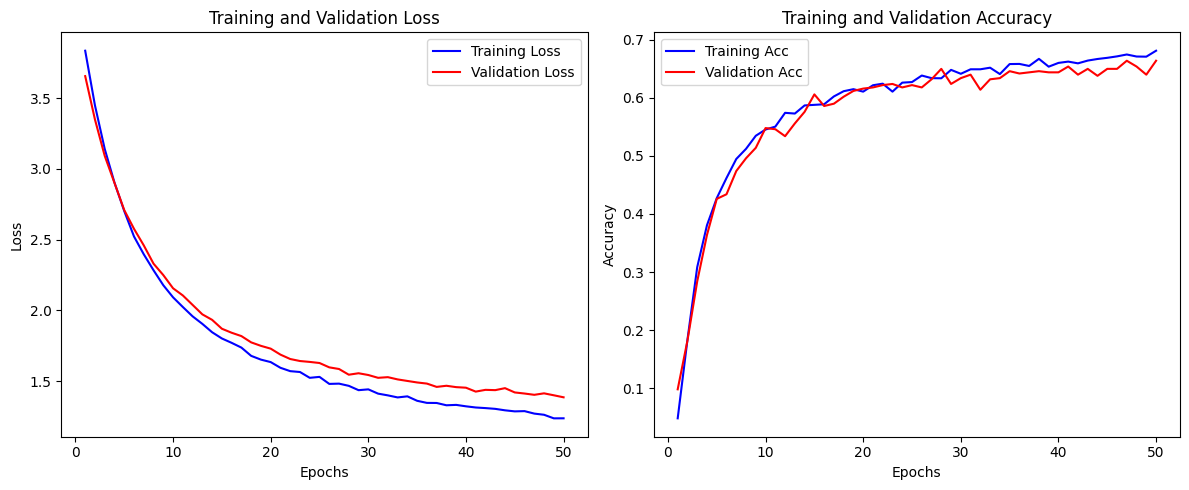

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
plt.plot(epochs, history['val_acc'], 'r-', label='Validation Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

avg_method = 'macro'

precision = precision_score(y_labels, y_preds, average=avg_method)
recall = recall_score(y_labels, y_preds, average=avg_method)
f1 = f1_score(y_labels, y_preds, average=avg_method)
accuracy = accuracy_score(y_labels, y_preds)

print(f"--- 전체 테스트 결과 ({avg_method} average) ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification Report (Precision, Recall, F1-score 출력)
# class_names = full_dataset.classes # (예: ['Bulbasaur', 'Pikachu', ...])
print("\n[Classification Report]")
print(classification_report(y_labels, y_preds, target_names=classes))


--- 전체 테스트 결과 (macro average) ---
Accuracy : 0.6080
Precision: 0.6218
Recall   : 0.6080
F1-Score : 0.5982

[Classification Report]
              precision    recall  f1-score   support

         cat       0.56      0.50      0.53        10
         dog       0.00      0.00      0.00        10
        bird       0.50      0.20      0.29        10
        fish       0.55      0.60      0.57        10
      rabbit       0.60      0.60      0.60        10
        duck       0.50      0.60      0.55        10
       horse       0.50      0.40      0.44        10
        lion       0.83      0.50      0.62        10
       tiger       0.00      0.00      0.00        10
        bear       0.40      0.60      0.48        10
    elephant       0.16      0.30      0.21        10
      monkey       1.00      0.20      0.33        10
         pig       0.36      0.40      0.38        10
         cow       0.33      0.40      0.36        10
     penguin       1.00      0.60      0.75        10
    